# Data formatting

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import cvxpy as cp
import seaborn as sns
import matplotlib

from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, check_array,check_is_fitted)
from statsmodels.tsa.arima_process import ArmaProcess
from google.colab import files
from google.colab import drive
drive.mount('/mnt/drive', force_remount=True)
from matplotlib import pyplot as plt
from cycler import cycler

Mounted at /mnt/drive


In [ ]:
df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()

df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

In [ ]:
df_1 = df_1[np.isfinite(df_1['filings_2020_p2'])]
df_2 = df_2[np.isfinite(df_2['filings_2020_p2'])]

In [ ]:
# Get record from FEMA API
url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?$format=csv&$allrecords=true"

# Make it to dataframe
dec = pd.read_csv(url)

# Make FIPS code
dec['fipsStateCode'] = dec['fipsStateCode'].astype(str).str.zfill(2)
dec['fipsCountyCode'] = dec['fipsCountyCode'].astype(str).str.zfill(3)
dec['FIPS'] = dec['fipsStateCode'] + dec['fipsCountyCode']
dec['FIPS'] = dec['FIPS'].astype(str).copy()

# Get a simpler dec
dec = dec[['disasterNumber', 'state', 'designatedArea', 'fipsStateCode', 'fipsCountyCode', 'FIPS']].copy()
dec = pd.merge(dec, df_dis, left_on='disasterNumber', right_on='Num', how='left').copy()
dec = dec.dropna(subset=["month_num"]).copy()
disaster_list = dec["disasterNumber"].unique().astype(str)

In [ ]:
sc_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC_ct.csv")
sc_ct['GEOID'] = sc_ct['TRACT'].astype(str).str.zfill(11).str.replace(r"\.0$", "", regex=True)
HD_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_ct.csv")
HD_ct = HD_ct.dropna(subset=['TRACT']).copy()
HD_ct['GEOID'] = HD_ct['TRACT'].astype(int).astype(str).str.zfill(11)
acs_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_ct.csv")
acs_ct['GEOID'] = acs_ct['GEOID'].astype(str).copy()

# Census Tract level

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [ ]:
# -----------------------------------
# Synthetic Control Class
# -----------------------------------
class SyntheticControl(BaseEstimator, RegressorMixin):
    def __init__(self):
        pass

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)
        w = cp.Variable(y_pre_co.shape[1])
        objective = cp.Minimize(cp.sum_squares(y_pre_co @ w - y_pre_tr))
        constraints = [cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(objective, constraints)
        self.loss_ = prob.solve(verbose=False)
        self.w_ = w.value
        self.is_fitted_ = True
        return self

    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(y_co)
        return y_co @ self.w_

# -----------------------------------
# reshape function
# -----------------------------------
def reshape_sc_data(df, geo_col, time_col, y_col, tr_geos, tr_start):
    df_piv = df.pivot_table(values=y_col, index=time_col, columns=geo_col)
    y_co = df_piv.drop(columns=tr_geos)
    y_tr = df_piv[tr_geos]
    y_pre_co = y_co[df_piv.index < tr_start]
    y_pre_tr = y_tr[df_piv.index < tr_start]
    y_post_co = y_co[df_piv.index >= tr_start]
    y_post_tr = y_tr[df_piv.index >= tr_start]
    return y_pre_co, y_pre_tr, y_post_co, y_post_tr

ストリーミング出力は最後の 5000 行に切り捨てられました。
--- Processing GEOID 12103025415 ---
  LOO remove: 12086981100
  LOO remove: 12011061003
  LOO remove: 12099007776
Pass: LOO sign stable -> save result
--- GEOID 12103025415 completed ---

--- Processing GEOID 12103025416 ---
  LOO remove: 12099005917
  LOO remove: 12086008101
  LOO remove: 12086017401
Pass: LOO sign stable -> save result
--- GEOID 12103025416 completed ---

--- Processing GEOID 12103025417 ---
  LOO remove: 12086007503
  LOO remove: 12086007707
  LOO remove: 12011070328
Pass: LOO sign stable -> save result
--- GEOID 12103025417 completed ---

--- Processing GEOID 12103025418 ---
  LOO remove: 12086008426
  LOO remove: 12086008604
  LOO remove: 12099007776
Pass: LOO sign stable -> save result
--- GEOID 12103025418 completed ---

--- Processing GEOID 12103025419 ---
  LOO remove: 12099007776
  LOO remove: 12086012200
  LOO remove: 12099005958
Pass: LOO sign stable -> save result
--- GEOID 12103025419 completed ---

--- Processing GEOID 12

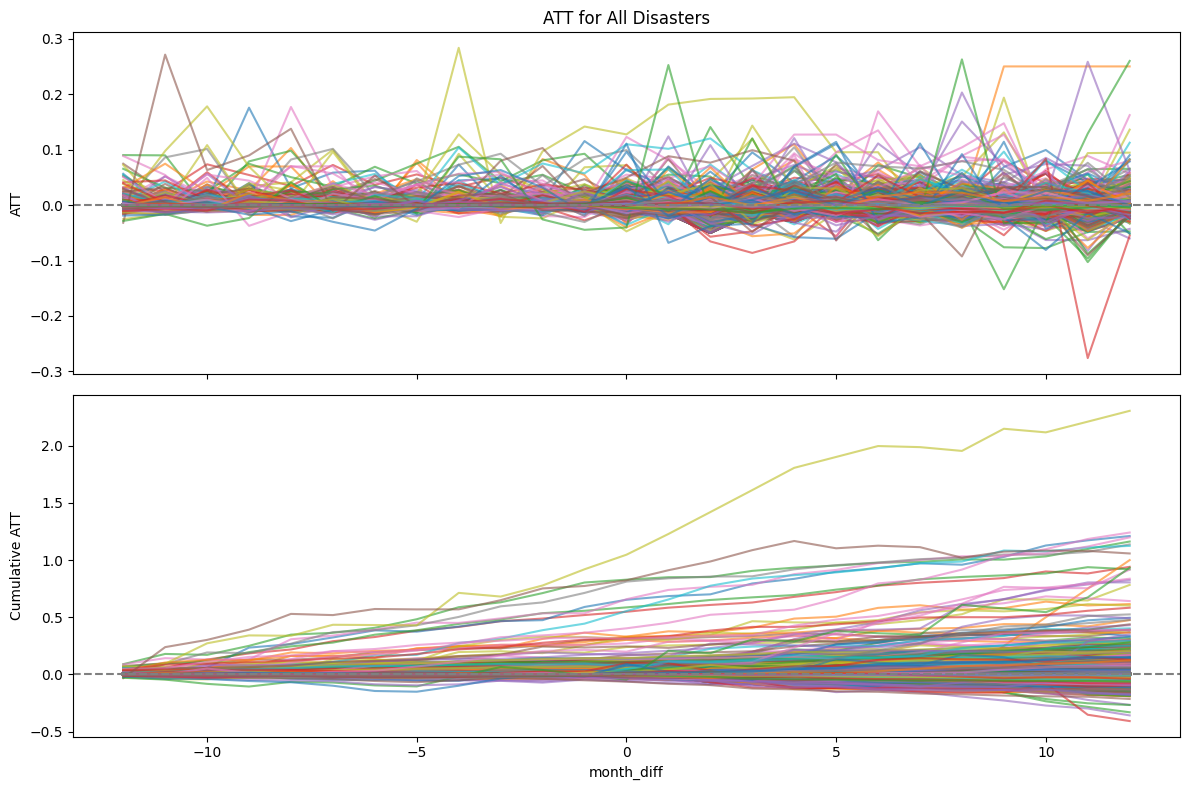

Filtered (passed) pairs: [(np.str_('4735'), np.int64(47157000100)), (np.str_('4735'), np.int64(47157000200)), (np.str_('4735'), np.int64(47157000300)), (np.str_('4735'), np.int64(47157000400)), (np.str_('4735'), np.int64(47157000600)), (np.str_('4735'), np.int64(47157000700)), (np.str_('4735'), np.int64(47157000800)), (np.str_('4735'), np.int64(47157001100)), (np.str_('4735'), np.int64(47157001400)), (np.str_('4735'), np.int64(47157001500)), (np.str_('4735'), np.int64(47157001600)), (np.str_('4735'), np.int64(47157001700)), (np.str_('4735'), np.int64(47157001900)), (np.str_('4735'), np.int64(47157002000)), (np.str_('4735'), np.int64(47157002400)), (np.str_('4735'), np.int64(47157002500)), (np.str_('4735'), np.int64(47157002600)), (np.str_('4735'), np.int64(47157003000)), (np.str_('4735'), np.int64(47157003100)), (np.str_('4735'), np.int64(47157003200)), (np.str_('4735'), np.int64(47157003500)), (np.str_('4735'), np.int64(47157003600)), (np.str_('4735'), np.int64(47157003800)), (np.str_

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

disaster_list = dec["disasterNumber"].unique().astype(str)
df_1['state'] = df_1['state'].astype(str)

att_all = {}
cum_att_all = {}
filtered_by_att = []

for disaster_id in disaster_list:
    print(f"\n=== Processing Disaster {disaster_id} ===")

    # --- FIPS & Treatment GEOIDs ---
    fips = dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "FIPS"].unique()
    treat_geoids = df_1.loc[df_1["GEOID"].astype(str).str[:5].isin(fips), "GEOID"].unique()
    print("Treat count:", len(treat_geoids))
    if len(treat_geoids) == 0:
        print(f"No treatment GEOIDs available for disaster {disaster_id}, skipping...")
        continue

    impact_month = int(dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "month_num"].unique()[0])

    # --- State selection ---
    state_code = str(fips[0])[:2]
    df_state = df_1[df_1["state"] == state_code].copy()
    print("State GEOIDs:", df_state["GEOID"].nunique())

    # --- month_diff trimming ---
    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    # --- Control candidates (same state, not treatment) ---
    control_geoids = df_trim.loc[~df_trim["GEOID"].isin(treat_geoids), "GEOID"].unique()
    print("Control candidates:", len(control_geoids))
    if len(control_geoids) == 0:
        print(f"No control GEOIDs available for disaster {disaster_id}, skipping...")
        continue

    # --- Only complete GEOIDs ---
    all_months = set(range(-12, 13))
    valid_geoids = [
        geo for geo in list(treat_geoids) + list(control_geoids)
        if all_months.issubset(set(df_trim.loc[df_trim["GEOID"] == geo, "month_diff"]))
    ]

    # --- Synthetic Control per treatment GEOID ---
    for geo in treat_geoids:
        print(f"\n--- Processing GEOID {geo} ---")
        if geo not in valid_geoids:
            print("Skip: treatment does not have full months")
            continue

        # データ構築：トリートメント + (valid & control)
        df_tr = df_trim[df_trim["GEOID"] == geo].copy()
        df_co = df_trim[
            df_trim["GEOID"].isin(valid_geoids) &
            df_trim["GEOID"].isin(control_geoids)
        ].copy()

        if df_co["GEOID"].nunique() == 0:
            print("Skip: no controls after filtering")
            continue

        df_sc = pd.concat([df_tr, df_co])

        y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
            df_sc, geo_col="GEOID", time_col="month_diff", y_col="filings_2020_p2",
            tr_geos=[geo], tr_start=0
        )

        if y_pre_co.isna().any().any() or y_pre_tr.isna().any().any():
            print("Skip: NaN in pre_period matrices")
            continue

        # ==== Full model fit ====
        model = SyntheticControl()
        model.fit(y_pre_co.values, y_pre_tr.mean(axis=1).values)

        y_co = pd.concat([y_pre_co, y_post_co])
        y_tr = pd.concat([y_pre_tr, y_post_tr])
        y_hat_full = model.predict(y_co.values)

        att_full = y_tr.mean(axis=1) - y_hat_full
        cum_att_full = att_full.cumsum()
        t_plus12_val = cum_att_full.get(12, np.nan)


        # ==== LOO: top3 donors by weight ====
        co_geoids = y_pre_co.columns.tolist()
        weights = pd.Series(model.w_, index=co_geoids)
        top3_geoids = weights.sort_values(ascending=False).head(3).index.tolist()

        loo_cum_atts = {}
        loo_t12_vals = []

        if len(top3_geoids) == 0:
            print("Skip: no donors to run LOO")
            continue

        for exclude_geo in top3_geoids:
            print(f"  LOO remove: {exclude_geo}")
            try:
                y_pre_co_loo = y_pre_co.drop(columns=[exclude_geo])
                y_post_co_loo = y_post_co.drop(columns=[exclude_geo])
                y_co_loo = pd.concat([y_pre_co_loo, y_post_co_loo])

                model_loo = SyntheticControl()
                model_loo.fit(y_pre_co_loo.values, y_pre_tr.mean(axis=1).values)

                y_hat_loo = model_loo.predict(y_co_loo.values)
                att_loo = y_tr.mean(axis=1) - y_hat_loo
                cum_att_loo = att_loo.cumsum()

                loo_cum_atts[exclude_geo] = cum_att_loo
                loo_t12_vals.append(cum_att_loo.get(12, np.nan))

            except Exception as e:
                print(f"   Error during LOO for {exclude_geo}: {e}")
                loo_cum_atts[exclude_geo] = pd.Series(np.nan, index=y_tr.index)
                loo_t12_vals.append(np.nan)

        if all(np.isnan(x) for x in loo_t12_vals):
            print("Skip: all LOO results are NaN")
            continue

        full_sign = np.sign(t_plus12_val)
        loo_signs = [np.sign(x) for x in loo_t12_vals if not np.isnan(x)]

        if len(loo_signs) > 0 and all(s == full_sign for s in loo_signs):
            print("Pass: LOO sign stable -> save result")
            key = f"{disaster_id}_{geo}"
            att_all[key] = att_full
            cum_att_all[key] = cum_att_full
            filtered_by_att.append((disaster_id, geo))
        else:
            print(f"Fail: sign mismatch (full={full_sign}, loo={loo_signs}) -> skip")
            continue

        print(f"--- GEOID {geo} completed ---")

# --- Plot ---
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for key in att_all:
    axs[0].plot(att_all[key].index, att_all[key], alpha=0.6, label=key)
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters")

for key in cum_att_all:
    axs[1].plot(cum_att_all[key].index, cum_att_all[key], alpha=0.6, label=key)
axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")
plt.tight_layout()
plt.show()

print("Filtered (passed) pairs:", filtered_by_att)


In [ ]:
import pandas as pd

# --- att_all -> DataFrame ---
att_list = []
for key, series in att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "ATT": series.values
    })
    att_list.append(df_tmp)

att_df = pd.concat(att_list, ignore_index=True)

# --- cum_att_all -> DataFrame ---
cum_att_list = []
for key, series in cum_att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "Cumulative_ATT": series.values
    })
    cum_att_list.append(df_tmp)

cum_att_df = pd.concat(cum_att_list, ignore_index=True)

# --- CSV ---
save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"
att_df.to_csv(save_dir + "att_all_LOO.csv", index=False)
cum_att_df.to_csv(save_dir + "cum_att_all_LOO.csv", index=False)

print("Saved att_all_LOO.csv and cum_att_all_LOO.csv with GEOID and disaster_id columns.")

Saved att_all_LOO.csv and cum_att_all_LOO.csv with GEOID and disaster_id columns.


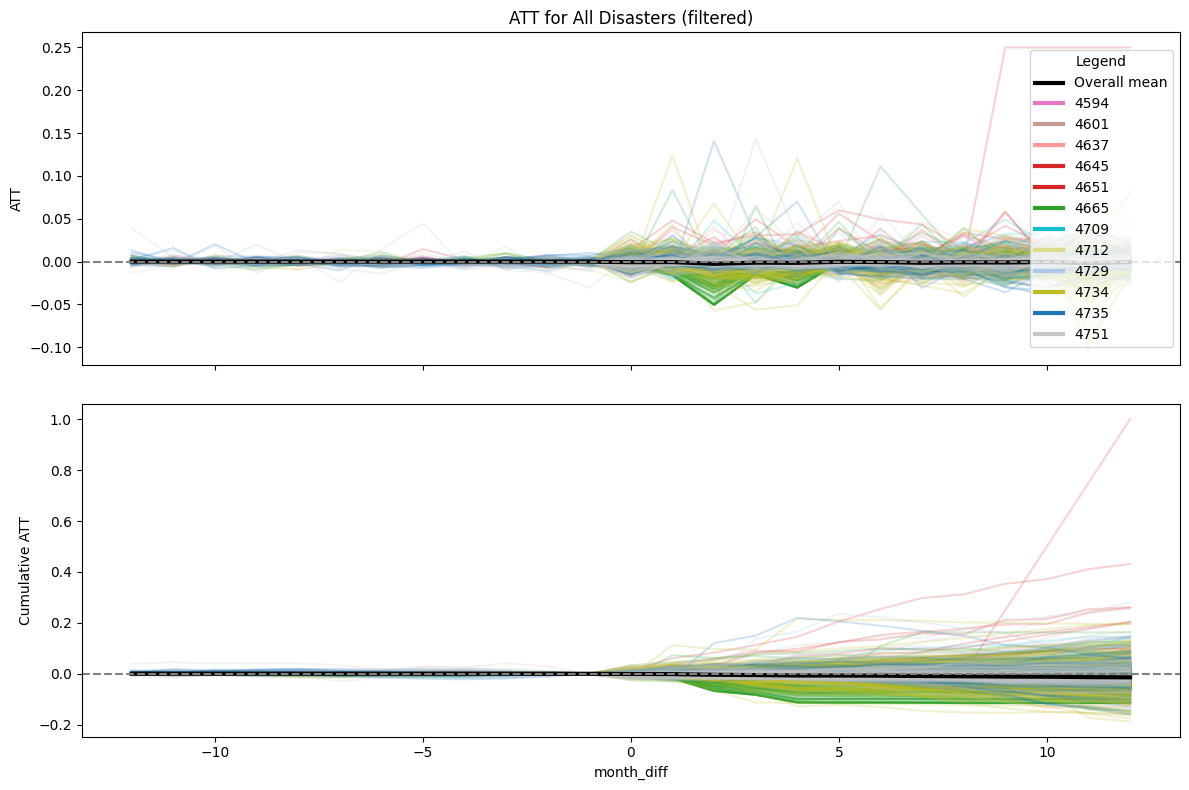

Filtered GEOIDs: ['47157000100', '47157000200', '47157000800', '47157001400', '47157001600', '47157001900', '47157002100', '47157002500', '47157002600', '47157002900', '47157003100', '47157003300', '47157003400', '47157003500', '47157003600', '47157003900', '47157004200', '47157004600', '47157006300', '47157006600', '47157007821', '47157008700', '47157008800', '47157009100', '47157009400', '47157009600', '47157010300', '47157010500', '47157010710', '47157011100', '47157011300', '47157011401', '47157020102', '47157020210', '47157020221', '47157020301', '47157020400', '47157020524', '47157020531', '47157020635', '47157020654', '47157020656', '47157020657', '47157020658', '47157020834', '47157020837', '47157020901', '47157020902', '47157021022', '47157021113', '47157021121', '47157021125', '47157021126', '47157021135', '47157021136', '47157021138', '47157021141', '47157021143', '47157021311', '47157021312', '47157021320', '47157021341', '47157021354', '47157021356', '47157021357', '471570

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/att_all_LOO.csv")
cum_att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all_LOO.csv")

# --- att_all to Dict ---
att_all = {}
for (disaster_id, geo), group in att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    att_all[key] = series

# --- cum_att_all to Dict ---
cum_att_all = {}
for (disaster_id, geo), group in cum_att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["Cumulative_ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    cum_att_all[key] = series


# --- Disaster list and colors ---
n_disasters = len(disaster_list)
cmap = plt.get_cmap('tab20')
colors = {disaster_list[i]: cmap(i / n_disasters) for i in range(n_disasters)}

# List to store GEOIDs that remain after filtering
filtered_geoids = []

# List to store all filtered ATT/Cumulative ATT series
all_att_series = []
all_cum_att_series = []

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
legend_plots = {}

# --- t = -1 ---
cum_minus1 = []
for key, series in cum_att_all.items():
    if -1 in series.index:
        cum_minus1.append(series.loc[-1])

cum_minus1 = np.array(cum_minus1)

# --- IQR ---
Q1 = np.quantile(cum_minus1, 0.25)
Q3 = np.quantile(cum_minus1, 0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# --- Filtering ---
filtered_geoids = []
all_att_series = []
all_cum_att_series = []
legend_plots = {}

for key, cum_series in cum_att_all.items():
    if -1 in cum_series.index:
        value_minus1 = cum_series.loc[-1]
        if lower <= value_minus1 <= upper:
            disaster_id, geo = key.split('_')
            color = colors.get(disaster_id, 'gray')

            # Plot individual GEOID lines
            axs[0].plot(att_all[key].index, att_all[key], alpha=0.2, color=color)
            axs[1].plot(cum_series.index, cum_series, alpha=0.2, color=color)

            # Add to filtered GEOID list
            filtered_geoids.append(geo)

            # Store for overall mean
            all_att_series.append(att_all[key])
            all_cum_att_series.append(cum_series)

            # For legend
            if disaster_id not in legend_plots:
                legend_plots[disaster_id] = color

# --- Compute overall mean (all disasters together) ---
if len(all_att_series) > 0:
    mean_att = np.mean([s.values for s in all_att_series], axis=0)
    mean_cum_att = np.mean([s.values for s in all_cum_att_series], axis=0)

    axs[0].plot(all_att_series[0].index, mean_att, color='black', linewidth=3, label='Overall mean')
    axs[1].plot(all_cum_att_series[0].index, mean_cum_att, color='black', linewidth=3, label='Overall mean')

# Add horizontal lines at zero
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters (filtered)")

axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

# Add legend for disasters and overall mean
for disaster_id, color in legend_plots.items():
    axs[0].plot([], [], color=color, label=disaster_id, linewidth=3)
    axs[1].plot([], [], color=color, label=disaster_id, linewidth=3)

axs[0].legend(title="Legend", fontsize=10)

plt.tight_layout()
plt.show()

print("Filtered GEOIDs:", filtered_geoids)

In [ ]:
# -------------------------------------------------
# Filtered -> Dict
# -------------------------------------------------
filtered_att_all = {}
filtered_cum_att_all = {}

for key, cum_series in cum_att_all.items():
    if -1 in cum_series.index:
        v = cum_series.loc[-1]
        if lower <= v <= upper:
            filtered_att_all[key] = att_all[key]
            filtered_cum_att_all[key] = cum_series

# -------------------------------------------------
# filtered_att_df
# -------------------------------------------------
filtered_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_att_all.items()}
)

filtered_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_att_all.values())).index
)

# -------------------------------------------------
# filtered_cum_att_df
# -------------------------------------------------
filtered_cum_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_cum_att_all.items()}
)

filtered_cum_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_cum_att_all.values())).index
)

save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"

filtered_att_df.to_csv(
    save_dir + "filtered_att_all_LOO.csv",
    index=False
)

filtered_cum_att_df.to_csv(
    save_dir + "filtered_cum_att_all_LOO.csv",
    index=False
)

print("Saved filtered_att_all_LOO.csv and filtered_cum_att_all_LOO.csv")

Saved filtered_att_all_LOO.csv and filtered_cum_att_all_LOO.csv


# Zip level

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [ ]:
# -----------------------------------
# Synthetic Control Class
# -----------------------------------
class SyntheticControl(BaseEstimator, RegressorMixin):
    def __init__(self):
        pass

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)
        w = cp.Variable(y_pre_co.shape[1])
        objective = cp.Minimize(cp.sum_squares(y_pre_co @ w - y_pre_tr))
        constraints = [cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(objective, constraints)
        self.loss_ = prob.solve(verbose=False)
        self.w_ = w.value
        self.is_fitted_ = True
        return self

    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(y_co)
        return y_co @ self.w_

# -----------------------------------
# reshape function
# -----------------------------------
def reshape_sc_data(df, geo_col, time_col, y_col, tr_geos, tr_start):
    df_piv = df.pivot_table(values=y_col, index=time_col, columns=geo_col)
    y_co = df_piv.drop(columns=tr_geos)
    y_tr = df_piv[tr_geos]
    y_pre_co = y_co[df_piv.index < tr_start]
    y_pre_tr = y_tr[df_piv.index < tr_start]
    y_post_co = y_co[df_piv.index >= tr_start]
    y_post_tr = y_tr[df_piv.index >= tr_start]
    return y_pre_co, y_pre_tr, y_post_co, y_post_tr


=== Processing Disaster 4766 ===
0
No treatment GEOIDs available for disaster 4766, skipping...

=== Processing Disaster 4760 ===
0
No treatment GEOIDs available for disaster 4760, skipping...

=== Processing Disaster 4759 ===
0
No treatment GEOIDs available for disaster 4759, skipping...

=== Processing Disaster 4752 ===
0
No treatment GEOIDs available for disaster 4752, skipping...

=== Processing Disaster 4745 ===
0
No treatment GEOIDs available for disaster 4745, skipping...

=== Processing Disaster 4739 ===
0
No treatment GEOIDs available for disaster 4739, skipping...

=== Processing Disaster 4735 ===
0
No treatment GEOIDs available for disaster 4735, skipping...

=== Processing Disaster 4732 ===
0
No treatment GEOIDs available for disaster 4732, skipping...

=== Processing Disaster 4730 ===
0
No treatment GEOIDs available for disaster 4730, skipping...

=== Processing Disaster 4729 ===
0
No treatment GEOIDs available for disaster 4729, skipping...

=== Processing Disaster 4726 

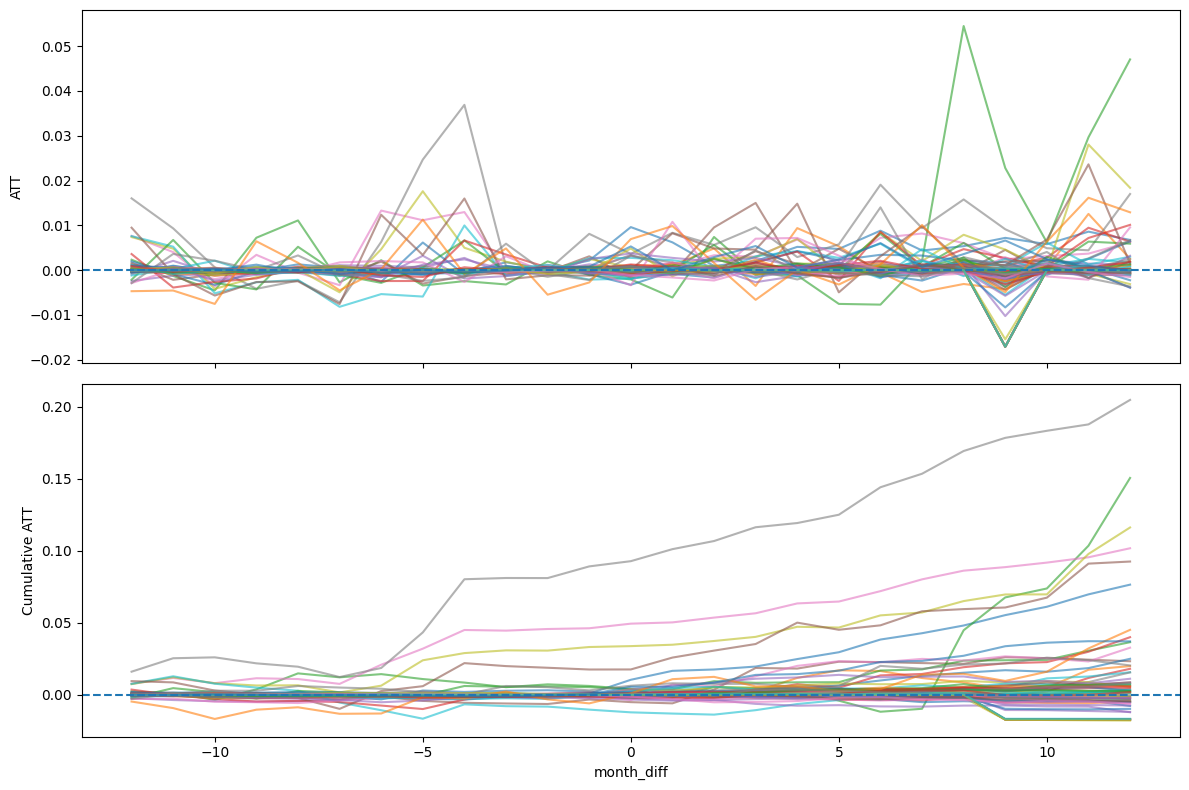

Filtered: [(np.str_('4644'), np.int64(23112)), (np.str_('4644'), np.int64(23113)), (np.str_('4644'), np.int64(23120)), (np.str_('4602'), np.int64(23112)), (np.str_('4602'), np.int64(23113)), (np.str_('4602'), np.int64(23120)), (np.str_('4602'), np.int64(23224)), (np.str_('4602'), np.int64(23225)), (np.str_('4602'), np.int64(23234)), (np.str_('4602'), np.int64(23236)), (np.str_('4602'), np.int64(23237)), (np.str_('4602'), np.int64(23803)), (np.str_('4602'), np.int64(23831)), (np.str_('4602'), np.int64(23832)), (np.str_('4602'), np.int64(23834)), (np.str_('4602'), np.int64(23836)), (np.str_('4602'), np.int64(23838)), (np.str_('4755'), np.int64(10466)), (np.str_('4755'), np.int64(10471)), (np.str_('4755'), np.int64(10475)), (np.str_('4755'), np.int64(10550)), (np.str_('4755'), np.int64(10704)), (np.str_('4755'), np.int64(10705)), (np.str_('4755'), np.int64(10803)), (np.str_('4755'), np.int64(11001)), (np.str_('4755'), np.int64(11003)), (np.str_('4755'), np.int64(11005)), (np.str_('4755'),

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

disaster_list = dec["disasterNumber"].unique().astype(str)

att_all = {}
cum_att_all = {}
filtered_by_att = []

for disaster_id in disaster_list:
    print(f"\n=== Processing Disaster {disaster_id} ===")

    # --- FIPS & Treatment GEOIDs ---
    fips = dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "FIPS"].unique()
    treat_geoids = df_2.loc[df_2["FIPS"].astype(str).str[:5].isin(fips), "GEOID"].unique()
    print(len(treat_geoids))
    if len(treat_geoids) == 0:
      print(f"No treatment GEOIDs available for disaster {disaster_id}, skipping...")
      continue
    impact_month = int(dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "month_num"].unique()[0])
    print(impact_month)

    # --- df_state & Control GEOIDs ---
    state_code = str(fips[0])[:2]
    df_state = df_2[df_2["state"] == state_code].copy()
    print(len(df_state["GEOID"].unique()))
    control_geoids = df_state.loc[~df_state["GEOID"].isin(treat_geoids), "GEOID"].unique()
    print(len(control_geoids))
   # Skip if there are no controls
    if len(control_geoids) == 0:
        print(f"No control GEOIDs available for disaster {disaster_id}, skipping...")
        continue

    # --- month_diff ---
    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    # --- Only complete GEOIDs---
    all_months = set(range(-12, 13))
    valid_geoids = [geo for geo in list(treat_geoids) + list(control_geoids)
                    if all_months.issubset(set(df_trim.loc[df_trim["GEOID"] == geo, "month_diff"]))]

    # =============================
    # Synthetic Control per GEOID
    # =============================
    for geo in treat_geoids:
        print(f"\n--- GEOID {geo} ---")
        if geo not in valid_geoids:
            print("Skip: incomplete treatment ZIP")
            continue

        # Treatment ZIP
        df_tr = df_trim[df_trim["GEOID"] == geo].copy()

        # Control ZIPs (valid only)
        df_co = df_trim[
            df_trim["GEOID"].isin(valid_geoids) &
            df_trim["GEOID"].isin(control_geoids)
        ].copy()

        if df_co["GEOID"].nunique() == 0:
            print("Skip: no valid controls")
            continue

        df_sc = pd.concat([df_tr, df_co])

        # ===== reshape =====
        y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
            df_sc, geo_col="GEOID", time_col="month_diff", y_col="filings_2020_p2",
            tr_geos=[geo], tr_start=0
        )

        if y_pre_co.isna().any().any() or y_pre_tr.isna().any().any():
            print("Skip: NaN in pre data")
            continue

        # ===== Full model =====
        model = SyntheticControl()
        model.fit(y_pre_co.values, y_pre_tr.mean(axis=1).values)

        y_co = pd.concat([y_pre_co, y_post_co])
        y_tr = pd.concat([y_pre_tr, y_post_tr])

        y_hat_full = model.predict(y_co.values)
        att_full = y_tr.mean(axis=1) - y_hat_full
        cum_att_full = att_full.cumsum()

        t_plus12_val = cum_att_full.loc[12]

        # ===== LOO Top-3 =====
        co_geoids = y_pre_co.columns.tolist()
        weights = pd.Series(model.w_, index=co_geoids)
        top3_geoids = weights.sort_values(ascending=False).head(3).index.tolist()

        if len(top3_geoids) == 0:
            print("Skip: no donors for LOO")
            continue

        loo_t12_vals = []
        loo_cum_atts = {}

        for ex in top3_geoids:
            print(" LOO remove:", ex)
            try:
                y_pre_co_loo = y_pre_co.drop(columns=[ex])
                y_post_co_loo = y_post_co.drop(columns=[ex])
                y_co_loo = pd.concat([y_pre_co_loo, y_post_co_loo])

                model_loo = SyntheticControl()
                model_loo.fit(y_pre_co_loo.values, y_pre_tr.mean(axis=1).values)

                y_hat_loo = model_loo.predict(y_co_loo.values)
                att_loo = y_tr.mean(axis=1) - y_hat_loo
                cum_att_loo = att_loo.cumsum()

                loo_cum_atts[ex] = cum_att_loo
                loo_t12_vals.append(cum_att_loo.loc[12])

            except Exception as e:
                print(" Error:", e)
                loo_t12_vals.append(np.nan)

        # ===== Sign stability check =====
        if all(np.isnan(x) for x in loo_t12_vals):
            print("Skip: all LOO NaN")
            continue

        full_sign = np.sign(t_plus12_val)
        loo_signs = [np.sign(x) for x in loo_t12_vals if not np.isnan(x)]

        if len(loo_signs) > 0 and all(s == full_sign for s in loo_signs):
            print("Pass: sign stable")
            key = f"{disaster_id}_{geo}"
            att_all[key] = att_full
            cum_att_all[key] = cum_att_full
            filtered_by_att.append((disaster_id, geo))
        else:
            print(f"Fail: sign mismatch full={full_sign}, LOO={loo_signs}")

# ===== Plot =====
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for key in att_all:
    axs[0].plot(att_all[key].index, att_all[key], alpha=0.6, label=key)
axs[0].axhline(0, linestyle="--")
axs[0].set_ylabel("ATT")

for key in cum_att_all:
    axs[1].plot(cum_att_all[key].index, cum_att_all[key], alpha=0.6)
axs[1].axhline(0, linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

plt.tight_layout()
plt.show()

print("Filtered:", filtered_by_att)


In [ ]:
import pandas as pd

# --- att_all -> DataFrame ---
att_list = []
for key, series in att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "ATT": series.values
    })
    att_list.append(df_tmp)

att_df = pd.concat(att_list, ignore_index=True)

# --- cum_att_all -> DataFrame ---
cum_att_list = []
for key, series in cum_att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "Cumulative_ATT": series.values
    })
    cum_att_list.append(df_tmp)

cum_att_df = pd.concat(cum_att_list, ignore_index=True)

# --- CSV ---
save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"
att_df.to_csv(save_dir + "att_all_zip_LOO.csv", index=False)
cum_att_df.to_csv(save_dir + "cum_att_all_zip_LOO.csv", index=False)

print("Saved att_all_zip_LOO.csv and cum_att_all_zip_LOO.csv with GEOID and disaster_id columns.")

Saved att_all_zip_LOO.csv and cum_att_all_zip_LOO.csv with GEOID and disaster_id columns.


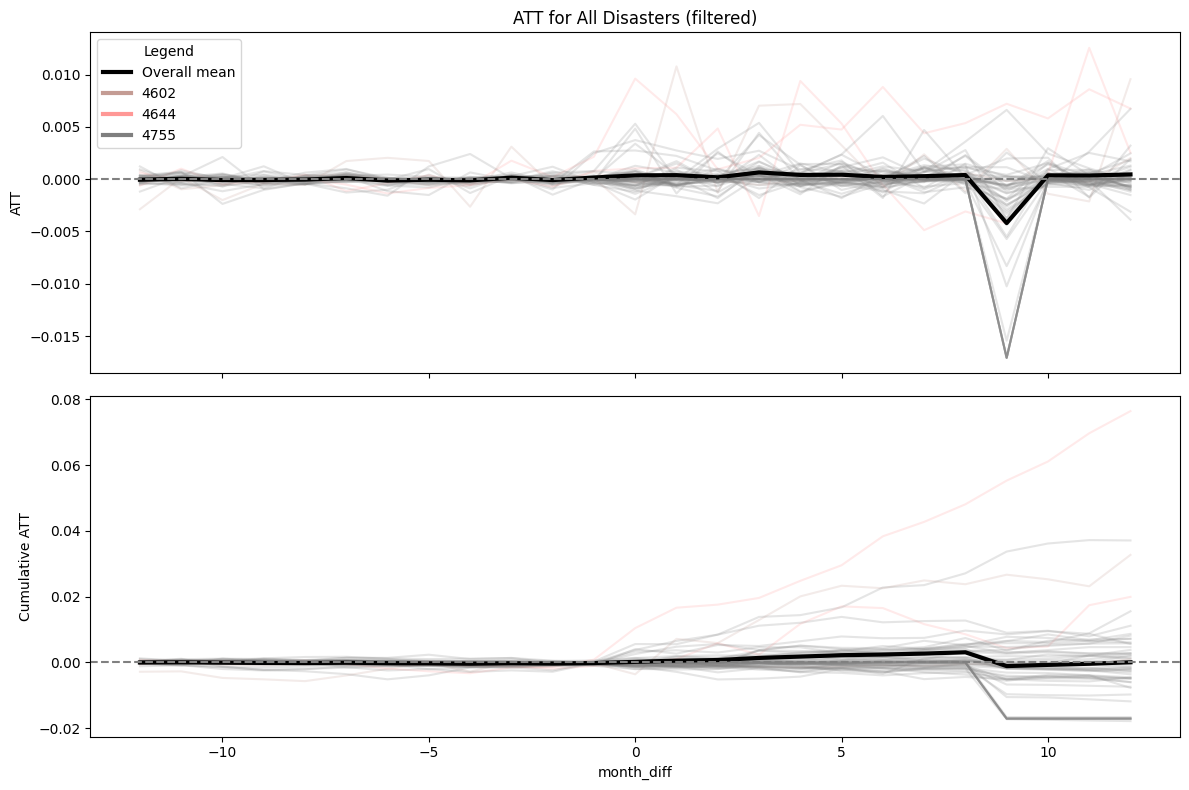

Filtered GEOIDs: ['23803', '23838', '23112', '23113', '10466', '10471', '10475', '10550', '10704', '10705', '10803', '11001', '11003', '11005', '11020', '11040', '11201', '11203', '11204', '11205', '11206', '11207', '11208', '11209', '11211', '11214', '11215', '11216', '11217', '11218', '11220', '11221', '11222', '11223', '11224', '11228', '11229', '11230', '11231', '11232', '11233', '11234', '11235', '11236', '11237', '11249', '11414', '11416', '11417', '11421', '11422', '11559', '11580', '11691']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/att_all_zip_LOO.csv")
cum_att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all_zip_LOO.csv")

# --- att_all to Dict ---
att_all = {}
for (disaster_id, geo), group in att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    att_all[key] = series

# --- cum_att_all to Dict ---
cum_att_all = {}
for (disaster_id, geo), group in cum_att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["Cumulative_ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    cum_att_all[key] = series


# --- Disaster list and colors ---
n_disasters = len(disaster_list)
cmap = plt.get_cmap('tab20')
colors = {disaster_list[i]: cmap(i / n_disasters) for i in range(n_disasters)}

# List to store GEOIDs that remain after filtering
filtered_geoids = []

# List to store all filtered ATT/Cumulative ATT series
all_att_series = []
all_cum_att_series = []

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
legend_plots = {}

# --- t = -1 ---
cum_minus1 = []
for key, series in cum_att_all.items():
    if -1 in series.index:
        cum_minus1.append(series.loc[-1])

cum_minus1 = np.array(cum_minus1)

# --- IQR ---
Q1 = np.quantile(cum_minus1, 0.25)
Q3 = np.quantile(cum_minus1, 0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# --- Filtering ---
filtered_geoids = []
all_att_series = []
all_cum_att_series = []
legend_plots = {}

for key, cum_series in cum_att_all.items():
    if -1 in cum_series.index:
        value_minus1 = cum_series.loc[-1]
        if lower <= value_minus1 <= upper:
            disaster_id, geo = key.split('_')
            color = colors.get(disaster_id, 'gray')

            # Plot individual GEOID lines
            axs[0].plot(att_all[key].index, att_all[key], alpha=0.2, color=color)
            axs[1].plot(cum_series.index, cum_series, alpha=0.2, color=color)

            # Add to filtered GEOID list
            filtered_geoids.append(geo)

            # Store for overall mean
            all_att_series.append(att_all[key])
            all_cum_att_series.append(cum_series)

            # For legend
            if disaster_id not in legend_plots:
                legend_plots[disaster_id] = color

# --- Compute overall mean (all disasters together) ---
if len(all_att_series) > 0:
    mean_att = np.mean([s.values for s in all_att_series], axis=0)
    mean_cum_att = np.mean([s.values for s in all_cum_att_series], axis=0)

    axs[0].plot(all_att_series[0].index, mean_att, color='black', linewidth=3, label='Overall mean')
    axs[1].plot(all_cum_att_series[0].index, mean_cum_att, color='black', linewidth=3, label='Overall mean')

# Add horizontal lines at zero
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters (filtered)")

axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

# Add legend for disasters and overall mean
for disaster_id, color in legend_plots.items():
    axs[0].plot([], [], color=color, label=disaster_id, linewidth=3)
    axs[1].plot([], [], color=color, label=disaster_id, linewidth=3)

axs[0].legend(title="Legend", fontsize=10)

plt.tight_layout()
plt.show()

print("Filtered GEOIDs:", filtered_geoids)

In [ ]:
# -------------------------------------------------
# Filtered -> Dict
# -------------------------------------------------
filtered_att_all = {}
filtered_cum_att_all = {}

for key, cum_series in cum_att_all.items():
    if -1 in cum_series.index:
        v = cum_series.loc[-1]
        if lower <= v <= upper:
            filtered_att_all[key] = att_all[key]
            filtered_cum_att_all[key] = cum_series

# -------------------------------------------------
# filtered_att_df
# -------------------------------------------------
filtered_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_att_all.items()}
)

filtered_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_att_all.values())).index
)

# -------------------------------------------------
# filtered_cum_att_df
# -------------------------------------------------
filtered_cum_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_cum_att_all.items()}
)

filtered_cum_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_cum_att_all.values())).index
)

save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"

filtered_att_df.to_csv(
    save_dir + "filtered_att_all_zip_LOO.csv",
    index=False
)

filtered_cum_att_df.to_csv(
    save_dir + "filtered_cum_att_all_zip_LOO.csv",
    index=False
)

print("Saved filtered_att_all_zip_LOO.csv and filtered_cum_att_all_zip_LOO.csv")


Saved filtered_att_all_zip_LOO.csv and filtered_cum_att_all_zip_LOO.csv


# Regression

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import cvxpy as cp
import seaborn as sns
import matplotlib
import statsmodels.api as sm
import matplotlib.gridspec as gridspec

from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, check_array,check_is_fitted)
from statsmodels.tsa.arima_process import ArmaProcess
from google.colab import files
from google.colab import drive
from matplotlib import pyplot as plt
from cycler import cycler

drive.mount('/mnt/drive', force_remount=True)

Mounted at /mnt/drive


In [ ]:
sc_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC_ct.csv")
sc_ct['GEOID'] = sc_ct['TRACT'].astype(str).str.zfill(11).str.replace(r"\.0$", "", regex=True)
HD_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_ct.csv")
HD_ct = HD_ct.dropna(subset=['TRACT']).copy()
HD_ct['GEOID'] = HD_ct['TRACT'].astype(int).astype(str).str.zfill(11)
acs_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_ct.csv")
acs_ct['GEOID'] = acs_ct['GEOID'].astype(str).copy()
sc_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC.csv")
sc_zip = sc_zip.dropna(subset=['zip']).copy()
sc_zip['GEOID'] = sc_zip['zip'].astype(int).astype(str).str.zfill(5)
HD_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_zip.csv")
HD_zip['zipCode'] = HD_zip['zipCode'].astype(str).str.strip()
HD_zip['zipCode_clean'] = HD_zip['zipCode'].str.extract(r'(\d+)', expand=False)
HD_zip = HD_zip.dropna(subset=['zipCode_clean']).copy()
HD_zip['GEOID'] = HD_zip['zipCode_clean'].astype(int).astype(str).str.zfill(5)
acs_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_zip.csv")
acs_zip['GEOID'] = acs_zip['GEOID'].astype(int).astype(str).str.zfill(5)

sc_all = pd.concat([sc_ct, sc_zip])
HD_all = pd.concat([HD_ct, HD_zip]).iloc[:, 1:10]
acs_all = pd.concat([acs_ct, acs_zip])

df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()
geo_city_df['GEOID'] = geo_city_df['GEOID'].astype(str)

In [ ]:
df_fil_ct = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_LOO.csv").T.iloc[1:]
df_fil_zip = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_zip_LOO.csv").T.iloc[1:]
df_combined = pd.concat([df_fil_ct, df_fil_zip])

df_combined = df_combined.reset_index()
df_combined = df_combined.rename(columns={'index': 'disaster_GEOID'})
df_combined[['disasterNumber', 'GEOID']] = df_combined['disaster_GEOID'].str.split('_', expand=True)

df_combined['disasterNumber'] = df_combined['disasterNumber'].astype(str)
df_combined['GEOID'] = df_combined['GEOID'].astype(str)

cum_df_12 = df_combined[[24,'GEOID']].copy()
cum_df_12 = cum_df_12.rename(columns={24: 'cum_att'})
cum_df_12["GEOID"] = cum_df_12["GEOID"].astype(str)

In [ ]:
# --- Create average filings dictionary ---
avg_dict = df_1.groupby("GEOID")["filings_2020_p2"].mean().to_dict()

# --- Merge all necessary data ---
merged_df = cum_df_12.merge(sc_all, on="GEOID", how="left") \
                     .merge(HD_all, on="GEOID", how="left") \
                     .merge(acs_all, on="GEOID", how="left") \
                     .merge(geo_city_df, on="GEOID", how="left")

merged_df = merged_df.rename(columns={"disaster_id": "disaster", "Cumulative_ATT": "cum_att"})
merged_df_clean = merged_df.replace([np.inf, -np.inf], np.nan)
merged_df_clean['D_TH'] = merged_df_clean['Tre_p']
merged_df_clean['Black_Population_Ratio'] = merged_df_clean['Black_Population'] / merged_df_clean['Total_Population']
merged_df_clean['zip'] = merged_df_clean['GEOID'].apply(lambda x: 1 if len(str(x)) == 5 else 0)

In [ ]:
merged_df_clean = merged_df_clean[merged_df_clean["city_y"] != "Richmond, VA"]

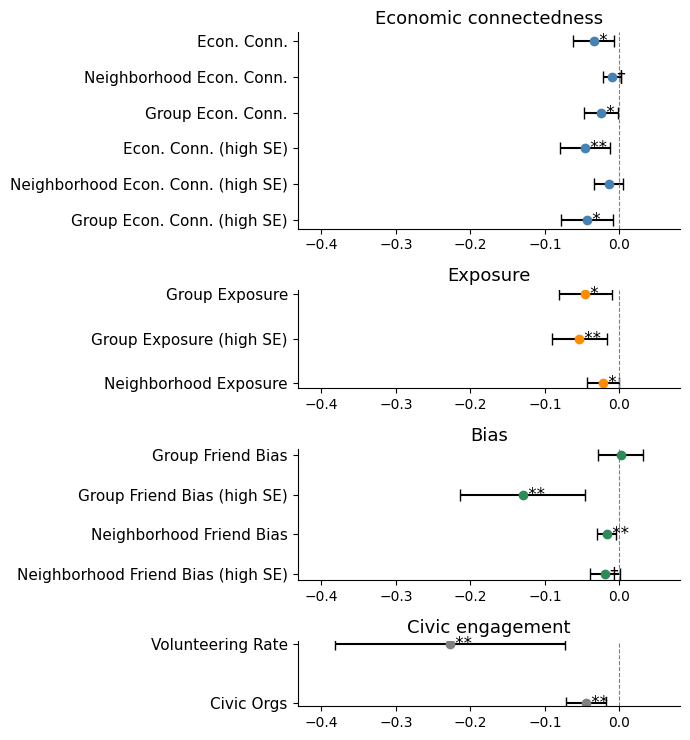

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ==============================
# Data
# ==============================
y_var = "cum_att"

x_vars = [
    "civic_organizations_zip",
    "volunteering_rate_zip",
    "nbhd_bias_high_zip",
    "nbhd_bias_zip",
    "bias_grp_mem_high_zip",
    "bias_grp_mem_zip",
    "nbhd_exposure_zip",
    "exposure_grp_mem_high_zip",
    "exposure_grp_mem_zip",
    "ec_grp_mem_high_zip",
    "nbhd_ec_high_zip",
    "ec_high_zip",
    "ec_grp_mem_zip",
    "nbhd_ec_zip",
    "ec_zip"
]

control_vars = [
    "Median_Household_Income",
    "Black_Population_Ratio",
    "Renter_Households",
    "disasterNumber",
    "D_TH"
]

# ==============================
# Labels & colors
# ==============================
x_label_mapping = {
    "civic_organizations_zip": "Civic Orgs",
    "volunteering_rate_zip": "Volunteering Rate",
    "nbhd_bias_high_zip": "Neighborhood Friend Bias (high SE)",
    "nbhd_bias_zip": "Neighborhood Friend Bias",
    "bias_grp_mem_high_zip": "Group Friend Bias (high SE)",
    "bias_grp_mem_zip": "Group Friend Bias",
    "nbhd_exposure_zip": "Neighborhood Exposure",
    "exposure_grp_mem_high_zip": "Group Exposure (high SE)",
    "exposure_grp_mem_zip": "Group Exposure",
    "ec_grp_mem_high_zip": "Group Econ. Conn. (high SE)",
    "nbhd_ec_high_zip": "Neighborhood Econ. Conn. (high SE)",
    "ec_high_zip": "Econ. Conn. (high SE)",
    "ec_grp_mem_zip": "Group Econ. Conn.",
    "nbhd_ec_zip": "Neighborhood Econ. Conn.",
    "ec_zip": "Econ. Conn."
}

def get_category(var):
    if "ec" in var:
        return "economic connectedness"
    elif "exposure" in var:
        return "exposure"
    elif "bias" in var:
        return "bias"
    else:
        return "civic engagement"

color_mapping = {
    "economic connectedness": "steelblue",
    "exposure": "darkorange",
    "bias": "seagreen",
    "civic engagement": "grey"
}

# ==============================
# Regression
# ==============================
def run_regression(
    df,
    vars_list,
    controls,
    y_var="cum_att",
    cluster_var="disaster"
):
    results = []
    regression_results = {}
    latex_results = {}

    for x in vars_list:
        # =========================
        # Subset
        # =========================
        cols = [y_var, x] + controls
        df_sub = df[cols].copy()

        # =========================
        # numeric coercion
        # =========================
        df_sub[y_var] = pd.to_numeric(df_sub[y_var], errors="coerce")
        df_sub[x] = pd.to_numeric(df_sub[x], errors="coerce")

        df_sub = (
            df_sub
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        # =========================
        # y / X
        # =========================
        y = df_sub[y_var].astype(float)
        X = df_sub.drop(columns=[y_var])

        # =========================
        # Explicit FE handling
        # =========================
        if "disasterNumber" in X.columns:
            X["disasterNumber"] = X["disasterNumber"].astype("category")

        # =========================
        # Dummy
        # =========================
        X = pd.get_dummies(X, drop_first=True)

        X = X.astype(float)

        X = sm.add_constant(X, has_constant="add")

        # =========================
        # Cluster
        # =========================
        groups = df_sub[cluster_var]

        model = sm.OLS(y, X).fit(
            cov_type="cluster",
            cov_kwds={"groups": groups}
        )
        regression_results[x] = model

        latex_results[x] = {
            "model": model,
            "nobs": int(model.nobs),
            "r2": model.rsquared
        }

        results.append({
            "x_variable": x,
            "Coefficient": model.params[x],
            "CI_Lower": model.conf_int().loc[x, 0],
            "CI_Upper": model.conf_int().loc[x, 1],
            "p_value": model.pvalues[x]
        })

    return pd.DataFrame(results),regression_results, latex_results



# ==============================
# Plot
# ==============================
def plot_coefficients_by_category(df):
    df = df.copy()
    df["category"] = df["x_variable"].apply(get_category)

    categories = list(df["category"].unique())[::-1]
    height_ratios = [len(df[df["category"] == c]) for c in categories]

    xmin = df["CI_Lower"].min() - 0.05
    xmax = df["CI_Upper"].max() + 0.05

    fig = plt.figure(figsize=(7, sum(height_ratios) * 0.5))
    gs = gridspec.GridSpec(len(categories), 1, height_ratios=height_ratios)

    for idx, cat in enumerate(categories):
        ax = fig.add_subplot(gs[idx])
        sub = df[df["category"] == cat].reset_index(drop=True)

        for i, row in sub.iterrows():
            color = color_mapping[cat]

            # significance
            if row["p_value"] < 0.001:
                star = "***"
            elif row["p_value"] < 0.01:
                star = "**"
            elif row["p_value"] < 0.05:
                star = "*"
            elif row["p_value"] < 0.1:
                star = "†"
            else:
                star = ""

            ax.errorbar(
                row["Coefficient"], i,
                xerr=[[row["Coefficient"] - row["CI_Lower"]],
                      [row["CI_Upper"] - row["Coefficient"]]],
                fmt="o",
                color=color,
                ecolor="black",
                capsize=4
            )

            if star:
                ax.text(row["Coefficient"], i, " " + star,
                        va="center", fontsize=12)

        ax.set_yticks(range(len(sub)))
        ax.set_yticklabels(
            [x_label_mapping.get(v, v) for v in sub["x_variable"]],
            fontsize=11
        )

        ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_xlim(xmin, xmax)
        ax.set_title(cat.capitalize(), fontsize=13)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

# ==============================
# Run
# ==============================
df_results, regression_results, latex_results = run_regression(
    df=merged_df_clean,
    vars_list=x_vars,
    controls=control_vars,
    y_var=y_var,
    cluster_var="disasterNumber"
)


plot_coefficients_by_category(df_results)


In [ ]:
for var, model in regression_results.items():
    print("=" * 80)
    print(var)
    print(model.summary())


civic_organizations_zip
                            OLS Regression Results                            
Dep. Variable:                cum_att   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     8.098
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           0.000311
Time:                        15:09:01   Log-Likelihood:                 3708.5
No. Observations:                1943   AIC:                            -7367.
Df Residuals:                    1918   BIC:                            -7228.
Df Model:                          24                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
co

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/loc

                            OLS Regression Results                            
Dep. Variable:                cum_att   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     2.074
Date:                Wed, 18 Feb 2026   Prob (F-statistic):              0.114
Time:                        15:09:02   Log-Likelihood:                 3695.4
No. Observations:                1934   AIC:                            -7341.
Df Residuals:                    1909   BIC:                            -7202.
Df Model:                          24                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 5
  warnings.warn('covariance of constraints does not have full '


In [ ]:
use_cols = x_vars + control_vars + [y_var]

df_used = merged_df_clean[use_cols].copy()

df_used = df_used.dropna(subset=control_vars)

desc_stats = df_used.describe()

desc_stats_t = desc_stats.T.iloc[::-1]

latex_table = desc_stats_t.to_latex(float_format="%.3f", index=True)

print(latex_table)

\begin{tabular}{lrrrrrrrr}
\toprule
 & count & mean & std & min & 25% & 50% & 75% & max \\
\midrule
cum_att & 1947.000 & -0.018 & 0.038 & -0.188 & -0.036 & -0.017 & 0.002 & 0.282 \\
D_TH & 1947.000 & 0.008 & 0.018 & 0.000 & 0.000 & 0.001 & 0.006 & 0.299 \\
disasterNumber & 1947.000 & 4550.006 & 447.132 & 1650.000 & 4601.000 & 4673.000 & 4675.000 & 4751.000 \\
Renter_Households & 1947.000 & 2813.919 & 5727.960 & 5.000 & 436.500 & 730.000 & 1296.000 & 29069.000 \\
Black_Population_Ratio & 1947.000 & 0.273 & 0.274 & 0.000 & 0.055 & 0.169 & 0.432 & 1.000 \\
Median_Household_Income & 1947.000 & 69531.428 & 33989.521 & 2499.000 & 45575.500 & 62212.000 & 84802.000 & 233542.000 \\
ec_zip & 1941.000 & 0.786 & 0.203 & 0.377 & 0.617 & 0.772 & 0.923 & 1.359 \\
nbhd_ec_zip & 1896.000 & 0.720 & 0.381 & 0.095 & 0.421 & 0.662 & 0.925 & 1.838 \\
ec_grp_mem_zip & 1934.000 & 0.867 & 0.248 & 0.351 & 0.669 & 0.849 & 1.036 & 1.579 \\
ec_high_zip & 1941.000 & 1.347 & 0.204 & 0.830 & 1.206 & 1.357 & 1.502 & 1

In [ ]:
pip install stargazer

In [ ]:
from statsmodels.iolib.summary2 import summary_col
import re
import math

# ==================================================
# 1. Variable groups
# ==================================================
demographics_vars = {
    "Median_Household_Income",
    "Black_Population_Ratio",
    "Renter_Households",
}

damage_index_vars = {
    "D_TH",
}

disaster_fe_prefix = "disaster"

# ==================================================
# 2. Label mapping
# ==================================================
x_label_mapping = {
    "civic_organizations_zip": "Civic Orgs",
    "volunteering_rate_zip": "Volunteering Rate",
    "nbhd_bias_high_zip": "Neighborhood Bias (high)",
    "nbhd_bias_zip": "Neighborhood Bias",
    "bias_grp_mem_high_zip": "Group Bias (high)",
    "bias_grp_mem_zip": "Group Bias",
    "nbhd_exposure_zip": "Neighborhood Exp.",
    "exposure_grp_mem_high_zip": "Group Exp. (high)",
    "exposure_grp_mem_zip": "Group Exp.",
    "ec_grp_mem_high_zip": "Group EC (high)",
    "nbhd_ec_high_zip": "Neighborhood EC (high)",
    "ec_high_zip": "EC (high)",
    "nbhd_ec_zip": "Neighborhood EC",
    "ec_grp_mem_zip": "Group EC",
    "ec_zip": "EC",
    "const": "const"
}

target_vars = list(x_label_mapping.keys())

# ==================================================
# 3. Helper functions
# ==================================================
def has_any(model, vars_set):
    return any(v in model.model.exog_names for v in vars_set)

def has_prefix(model, prefix):
    return any(v.startswith(prefix) for v in model.model.exog_names)

# ==================================================
# 4. Build LaTeX table
# ==================================================
def format_latex_table(models, start_idx):

    table = summary_col(
        models,
        stars=True,
        model_names=[f"({i})" for i in range(start_idx, start_idx + len(models))],
        info_dict={
            "Damage index": lambda x: "Yes" if has_any(x, damage_index_vars) else "No",
            "Demographics": lambda x: "Yes" if has_any(x, demographics_vars) else "No",
            "Disaster FE": lambda x: "Yes" if has_prefix(x, disaster_fe_prefix) else "No",
            "N": lambda x: f"{int(x.nobs)}",
            "R-squared": lambda x: f"{x.rsquared:.3f}",
        },
    )

    df = table.tables[0]

    # ----------------------------------------------
    # ① Vars
    # ----------------------------------------------
    keep_pos = set()
    n = len(df)
    summary_rows = {"R-squared", "R-squared Adj.", "N", "Damage index", "Demographics", "Disaster FE"}

    for i in range(n):
        idx = df.index[i]
        base = re.sub(r"\(.*\)", "", idx).strip()

        if base in target_vars:
            keep_pos.add(i)
            if i + 1 < n:
                keep_pos.add(i + 1)
        elif base in summary_rows:
            keep_pos.add(i)

    df = df.iloc[sorted(keep_pos)]

    # ----------------------------------------------
    # ② index label
    # ----------------------------------------------
    new_index = []
    last_label = ""

    for idx in df.index:
        base = re.sub(r"\(.*\)", "", idx).strip()

        if base in x_label_mapping:
            label = x_label_mapping[base]
            last_label = label
        else:
            if "(" in idx:
                label = f"{last_label} {idx}"
            else:
                label = base

        new_index.append(label)

    df.index = new_index

    # ----------------------------------------------
    # ③ LaTeX
    # ----------------------------------------------
    table.tables[0] = df
    latex = table.as_latex()

    latex = latex.replace(
        r"\begin{table}",
        r"\begin{table}\footnotesize"
    )

    latex = re.sub(
        r"(-?\d+\.\d+)",
        lambda m: f"{float(m.group()):.3f}",
        latex,
    )

    latex = re.sub(
        r"(\*{1,3})",
        r"$^{\\tiny \1}$",
        latex
    )

    return latex

# ==================================================
# 5. Split models
# ==================================================
models = [v["model"] for v in reversed(latex_results.values())]

mid = math.ceil(len(models) / 2)
models_left = models[:mid]
models_right = models[mid:]

latex_left = format_latex_table(models_left, 1)
latex_right = format_latex_table(models_right, mid + 1)

print(latex_left)
print(latex_right)


\begin{table}\footnotesize
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllllllll}
\hline
                       & (1)       & (2)      & (3)       & (4)        & (5)      & (6)       & (7)       & (8)         \\
\hline
const                  & 0.017    & -0.004  & 0.012    & 0.046$^{\tiny *}$    & 0.004   & 0.049$^{\tiny *}$   & 0.034    & 0.054$^{\tiny **}$    \\
                       & (0.017)  & (0.010) & (0.016)  & (0.024)   & (0.015) & (0.027)  & (0.021)  & (0.025)    \\
EC                     & -0.035$^{\tiny **}$ &          &           &            &          &           &           &             \\
                       & (0.014)  &          &           &            &          &           &           &             \\
Neighborhood EC        &           & -0.010$^{\tiny *}$ &           &            &          &           &           &             \\
                       &           & (0.006) &           &            &          &           &           &             \\
G